# Case118 IEEE 118-bus scalability visualization

Following the style of `ess_result_vis.ipynb`, this notebook visualizes EIFICA vs FICA results on the case118 system:
- **Part 1**: Imports and parameter setup
- **Part 2**: Load data
- **Part 3**: FICA vs EIFICA paired statistics
- **Part 4**: Solve-time comparison (log y-axis)
- **Part 5**: Out-of-sample satisfaction comparison
- **Part 6**: Speedup boxplots
- **Part 7**: case24 vs case118 cross-system solve-time comparison

## Part 1: Imports and parameter setup

In [9]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
warnings.filterwarnings('ignore', message='.*findfont.*')

#  Academic plotting styleconsistent with `ess_result_vis`
plt.style.use('default')
plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Liberation Serif', 'FreeSerif', 'serif'],
    'legend.fontsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'mathtext.fontset': 'cm',
})

#  Experiment parametersconsistent with `run_case118_ess_experiment.py`
method_list         = ['FICA', 'EIFICA']
eps_theta_pair_list = [(0.03, 0.06), (0.05, 0.10), (0.08, 0.12), (0.10, 0.15)]
N_WDR_list          = [50, 80, 100, 150, 200, 250, 300, 350]
seed_list           = [0, 10000, 20000, 30000, 40000]
num_ESS             = 6

#  Path configuration 
cwd = os.getcwd()
if os.path.basename(cwd) == 'case118' and os.path.basename(os.path.dirname(cwd)) == 'case_study_ess_results':
    THIS_DIR = cwd
    ROOT_DIR = os.path.dirname(os.path.dirname(cwd))
else:
    ROOT_DIR = cwd
    THIS_DIR = os.path.join(ROOT_DIR, 'case_study_ess_results', 'case118')
csv_path   = os.path.join(THIS_DIR, 'progress_case118.csv')
csv_24     = os.path.join(ROOT_DIR, 'case_study_ess_results', 'case24', 'progress.csv')
fig_dir    = os.path.join(ROOT_DIR, 'figure', 'case118_ess')
os.makedirs(fig_dir, exist_ok=True)

print(f"case118 CSV: {os.path.relpath(csv_path, project_root).replace(os.sep, '/')}  exists={os.path.exists(csv_path)}")
print(f"case24  CSV: {os.path.relpath(csv_24, project_root).replace(os.sep, '/')}    exists={os.path.exists(csv_24)}")
print(f"Figure directory:    {os.path.relpath(fig_dir, project_root).replace(os.sep, '/')}")


case118 CSV: case_study_ess_results/case118/progress_case118.csv  exists=True
case24  CSV: case_study_ess_results/case24/progress.csv    exists=True
Figure directory:    figure/case118_ess


## Part 2: Load data

In [10]:
df = pd.read_csv(csv_path)
df['satisfied_rate'] = df['satisfied_rate'] * 100   # convert to percentage

print(f'case118 record count: {len(df)}')
print(f'Status distribution: {df["status"].value_counts().to_dict()}')
print(f'Method distribution: {df["method"].value_counts().to_dict()}')
print()

piv_time = df.pivot_table(values='solve_time', index='N_WDR', columns='method', aggfunc='mean').round(1)
piv_time['FICA/EIFICA ratio'] = (piv_time['FICA']/piv_time['EIFICA']).round(2)
print('=== Mean solve time (s) and speedup ===')
display(piv_time)

case118 record count: 320
Status distribution: {'OK': 320}
Method distribution: {'EIFICA': 160, 'FICA': 160}

=== Mean solve time (s) and speedup ===


method,EIFICA,FICA,FICA/EIFICA ratio
N_WDR,,,
50,98.0000,104.7000,1.0700
80,108.4000,119.4000,1.1000
100,112.7000,128.4000,1.1400
150,128.0000,150.6000,1.1800
200,145.4000,811.9000,5.5800
250,161.2000,1085.8000,6.7400
300,179.4000,1376.2000,7.6700
350,251.6000,1771.7000,7.0400


## Part 3: FICA vs EIFICA paired statistics

In [11]:
merge_keys = ['epsilon', 'theta', 'N_WDR', 'seed']
FICA_df   = df[df['method'] == 'FICA'].copy()
EIFICA_df = df[df['method'] == 'EIFICA'].copy()
merged_df = pd.merge(FICA_df, EIFICA_df, on=merge_keys, suffixes=('_FICA', '_EIFICA'))

merged_df['speedup']       = merged_df['solve_time_FICA'] / merged_df['solve_time_EIFICA']
merged_df['cost_diff_pct'] = (merged_df['obj_value_EIFICA'] - merged_df['obj_value_FICA']) \
                              / merged_df['obj_value_FICA'].abs() * 100
merged_df['jcc_diff']      = merged_df['satisfied_rate_EIFICA'] - merged_df['satisfied_rate_FICA']

stats = merged_df.groupby(['epsilon', 'theta', 'N_WDR']).agg(
    speedup_mean  =('speedup',       'mean'),
    speedup_std   =('speedup',       'std'),
    cost_diff_mean=('cost_diff_pct', 'mean'),
    cost_diff_std =('cost_diff_pct', 'std'),
    jcc_diff_mean =('jcc_diff',      'mean'),
    n_pairs       =('speedup',       'count'),
).reset_index()

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
display(stats)

,epsilon,theta,N_WDR,speedup_mean,speedup_std,cost_diff_mean,cost_diff_std,jcc_diff_mean,n_pairs
0,0.0300,0.0600,50,1.0598,0.0169,-0.0003,0.0004,-67.4200,5
1,0.0300,0.0600,80,1.0454,0.0403,-0.0002,0.0001,-48.7880,5
2,0.0300,0.0600,100,1.1612,0.0139,-0.0001,0.0001,-18.3640,5
3,0.0300,0.0600,150,1.2078,0.0099,-0.0001,0.0001,-10.8120,5
4,0.0300,0.0600,200,5.6851,0.0812,-0.0000,0.0000,-0.9400,5
5,0.0300,0.0600,250,6.6989,0.6296,-0.0000,0.0000,-0.9440,5
6,0.0300,0.0600,300,7.4895,0.2301,-0.0000,0.0000,-0.7880,5
7,0.0300,0.0600,350,8.4701,0.6036,-0.0000,0.0000,-0.7840,5
8,0.0500,0.1000,50,1.0087,0.0301,-0.0001,0.0001,-55.3480,5
9,0.0500,0.1000,80,1.1318,0.0086,-0.0000,0.0001,-1.2200,5


## Part 4: Solve-time comparison (2x2, log y-axis)

Saved: figure/case118_ess/case118_time_comparison.pdf


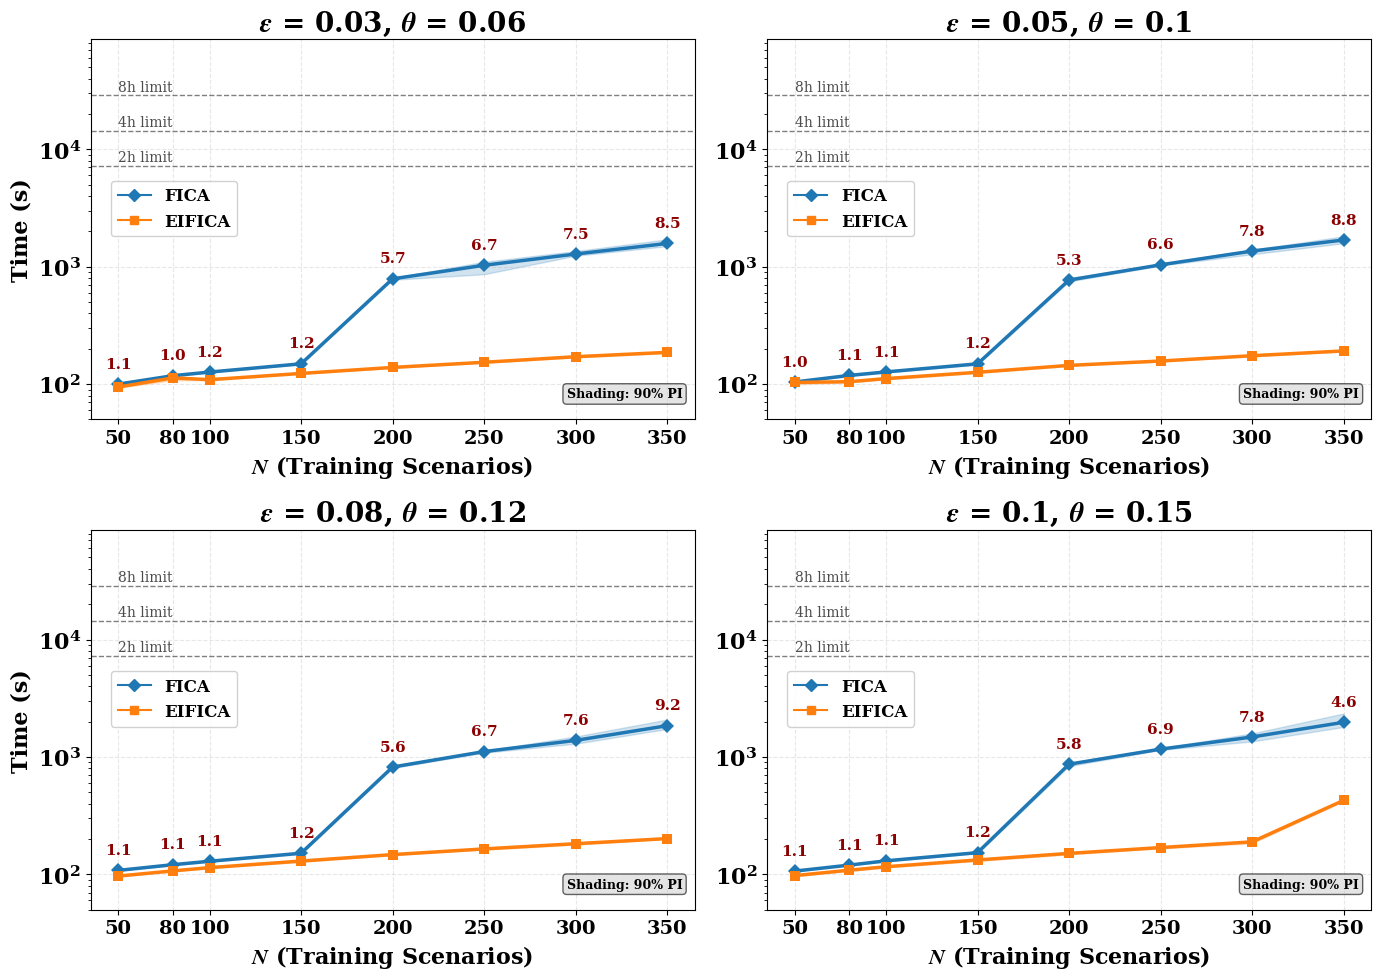

In [12]:
from matplotlib.lines import Line2D

palette = {
    'EIFICA': sns.color_palette('tab10')[1],   # orange
    'FICA':   sns.color_palette('tab10')[0],   # blue
}
marker_map = {'FICA': 'D', 'EIFICA': 's'}
timelimit  = 28800   # case118 time limit: 8 hours

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = df[(df['epsilon'] == eps) & (df['theta'] == theta)].copy()

    for method in ['FICA', 'EIFICA']:
        df_m = df_plot[df_plot['method'] == method]
        if not df_m.empty:
            sns.lineplot(
                x='N_WDR', y='solve_time', data=df_m, ax=ax,
                color=palette[method],
                estimator='mean', errorbar=('pi', 100),
                marker=marker_map[method], n_boot=1000,
                linestyle='-',
                markersize=7, markeredgewidth=0, linewidth=2.5,
            )

    ax.axhline(timelimit, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(50, timelimit*1.1, '8h limit', fontsize=10, color='black', alpha=0.7)
    ax.axhline(14400, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(50, 14400*1.1, '4h limit', fontsize=10, color='black', alpha=0.7)
    ax.axhline(7200, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(50, 7200*1.1, '2h limit', fontsize=10, color='black', alpha=0.7)

    # Speedup annotation
    t_fica   = df_plot[df_plot['method'] == 'FICA'].groupby('N_WDR')['solve_time'].mean()
    t_eifica = df_plot[df_plot['method'] == 'EIFICA'].groupby('N_WDR')['solve_time'].mean()
    for n_wdr in t_fica.index.intersection(t_eifica.index):
        spd = t_fica[n_wdr] / t_eifica[n_wdr]
        ax.text(n_wdr, t_fica[n_wdr] * 1.3, f'{spd:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='darkred')

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Time (s)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=16)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(50, timelimit * 3)
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()

    custom_lines = [
        Line2D([0], [0], color=palette['FICA'],   marker='D', linestyle='-', label='FICA'),
        Line2D([0], [0], color=palette['EIFICA'], marker='s', linestyle='-', label='EIFICA'),
    ]
    ax.legend(custom_lines, ['FICA', 'EIFICA'],
              loc='upper left', bbox_to_anchor=(0.02, 0.65),
              framealpha=0.9, prop={'weight': 'bold', 'size': 12})
    ax.text(0.98, 0.05, 'Shading: 90% PI', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.6))

# plt.suptitle('IEEE 118-Bus: EIFICA vs FICA Solve Time Comparison\n'
#              '(red labels = speedup ratio FICA/EIFICA)',
#              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'case118_time_comparison.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

## Part 5: Out-of-sample satisfaction comparison

Saved: figure/case118_ess/case118_jcc_comparison.pdf


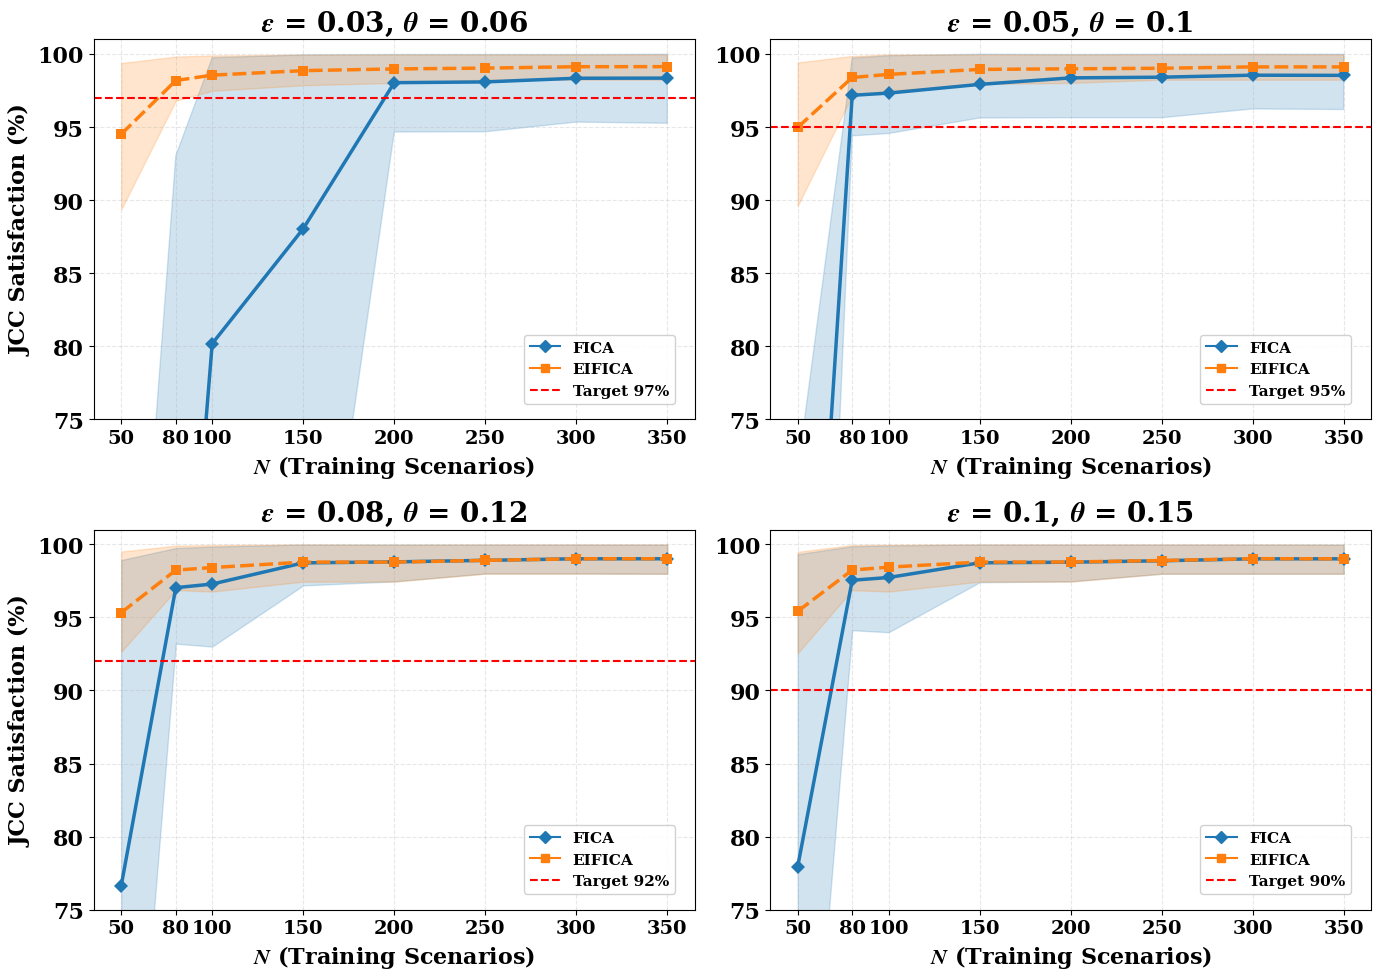

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = df[(df['epsilon'] == eps) & (df['theta'] == theta)].copy()

    if not df_plot.empty:
        sns.lineplot(
            x='N_WDR', y='satisfied_rate', data=df_plot, ax=ax,
            hue='method', estimator='mean', errorbar=('pi', 100),
            style='method',
            markers=['D', 's'], n_boot=1000,
            markersize=7, markeredgewidth=0, linewidth=2.5,
        )

    target = 100 * (1 - eps)
    ax.axhline(target, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('JCC Satisfaction (%)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=16)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.set_ylim(75, 101)
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()

    custom_lines = [
        Line2D([0], [0], color=sns.color_palette('tab10')[0], marker='D', linestyle='-', label='FICA'),
        Line2D([0], [0], color=sns.color_palette('tab10')[1], marker='s', linestyle='-', label='EIFICA'),
        Line2D([0], [0], color='red', linestyle='--', label=f'Target {target:.0f}%'),
    ]
    ax.legend(custom_lines, ['FICA', 'EIFICA', f'Target {target:.0f}%'],
              loc='lower right', bbox_to_anchor=(0.98, 0.02),
              framealpha=0.9, prop={'weight': 'bold', 'size': 11})

# plt.suptitle('IEEE 118-Bus: Out-of-Sample JCC Satisfaction Rate',
#              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'case118_jcc_comparison.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

## Part 6: Speedup boxplots

Saved: figure/case118_ess/case118_speedup_boxplot.pdf


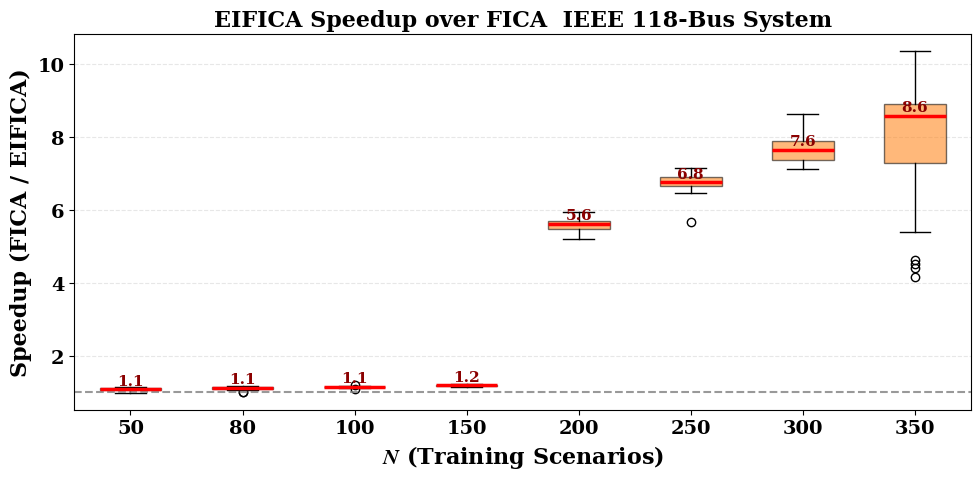


===  ===
        mean  median    min     max
N_WDR                              
50    1.0700  1.0700 0.9800  1.1300
80    1.1000  1.1100 1.0000  1.1600
100   1.1400  1.1400 1.0800  1.1800
150   1.1800  1.1800 1.1300  1.2200
200   5.5800  5.6200 5.2000  5.9300
250   6.7300  6.7500 5.6600  7.1600
300   7.6700  7.6300 7.1300  8.6400
350   7.7600  8.5800 4.1700 10.3500


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

data_box = [merged_df[merged_df['N_WDR'] == n]['speedup'].dropna().values
            for n in N_WDR_list]
bp = ax.boxplot(data_box, positions=range(len(N_WDR_list)), patch_artist=True,
           widths=0.55, showfliers=True,
           medianprops=dict(color='red', linewidth=2.5),
           boxprops=dict(facecolor=sns.color_palette('tab10')[1], alpha=0.55))

# 
for k, n in enumerate(N_WDR_list):
    med = merged_df[merged_df['N_WDR'] == n]['speedup'].median()
    ax.text(k, med + 0.05, f'{med:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkred')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_xticks(range(len(N_WDR_list)))
ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
ax.set_ylabel('Speedup (FICA / EIFICA)', fontsize=16, fontweight='bold')
ax.set_title('EIFICA Speedup over FICA  IEEE 118-Bus System', fontsize=16, fontweight='bold')
ax.tick_params(axis='y', which='major', labelsize=14)
plt.setp(ax.get_yticklabels(), fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(fig_dir, 'case118_speedup_boxplot.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

print(f'\n===  ===')
print(merged_df.groupby('N_WDR')['speedup'].agg(['mean','median','min','max']).round(2).to_string())

## Part 7: case24 vs case118  EIFICA 

Show EIFICA solve times on the two systems to demonstrate scalability.

Saved: figure/case118_ess/case118_vs_case24_eifica_time.pdf


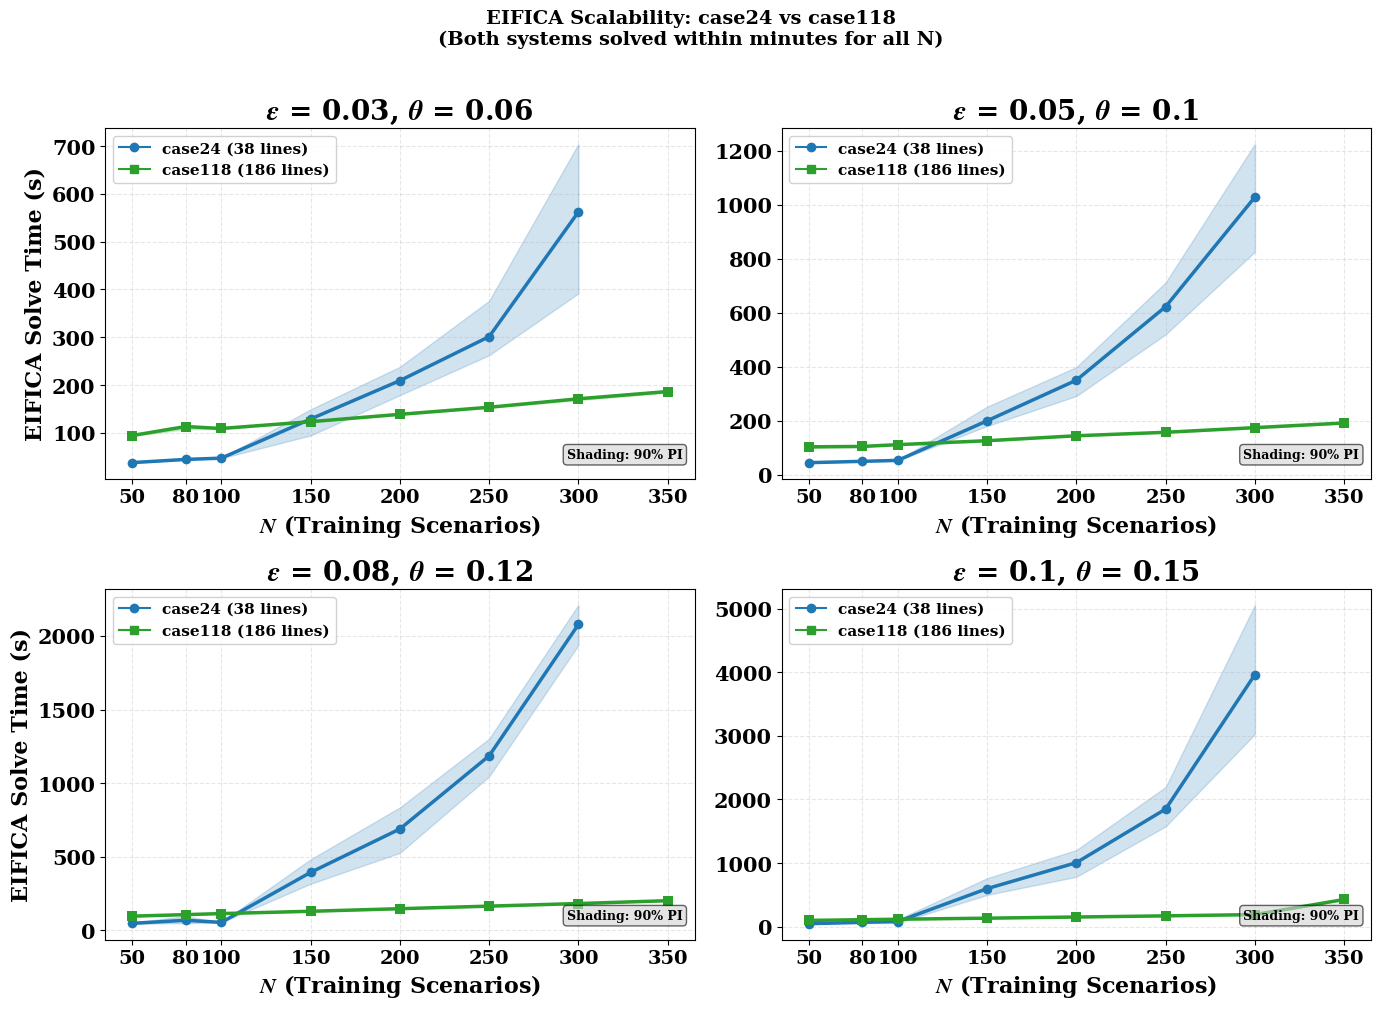


=== EIFICA Means===
         case24  case118  118/24 ratio
N_WDR                                 
50      43.9000  98.0000        2.2300
80      57.7000 108.4000        1.8800
100     58.6000 112.7000        1.9200
150    330.0000 128.0000        0.3900
200    563.6000 145.4000        0.2600
250    989.9000 161.2000        0.1600
300   1908.7000 179.4000        0.0900
350         NaN 251.6000           NaN


In [15]:
# Load case24 data
df24 = pd.read_csv(csv_24)
df24['network'] = 'case24 (38 lines)'
df24 = df24.rename(columns={'epsilon': 'epsilon', 'solve_time': 'solve_time',
                             'satisfied_rate': 'satisfied_rate_raw'})
df24['satisfied_rate'] = df24['satisfied_rate_raw'] * 100

df118 = df.copy()
df118['network'] = 'case118 (186 lines)'

# Keep EIFICA only
e24  = df24[df24['method'] == 'EIFICA'].copy()
e118 = df118[df118['method'] == 'EIFICA'].copy()

palette_net = {
    'case24 (38 lines)':   sns.color_palette('tab10')[0],
    'case118 (186 lines)': sns.color_palette('tab10')[2],
}
marker_net = {'case24 (38 lines)': 'o', 'case118 (186 lines)': 's'}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    for net, dfn in [('case24 (38 lines)', e24), ('case118 (186 lines)', e118)]:
        sub = dfn[(dfn['epsilon'] == eps) & (dfn['theta'] == theta)]
        if not sub.empty:
            sns.lineplot(
                x='N_WDR', y='solve_time', data=sub, ax=ax,
                color=palette_net[net],
                estimator='mean', errorbar=('pi', 100), n_boot=1000,
                marker=marker_net[net],
                markersize=7, markeredgewidth=0, linewidth=2.5,
                label=net,
            )

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('EIFICA Solve Time (s)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()

    custom_lines = [
        Line2D([0],[0], color=palette_net['case24 (38 lines)'],
               marker='o', linestyle='-', label='case24 (38 lines)'),
        Line2D([0],[0], color=palette_net['case118 (186 lines)'],
               marker='s', linestyle='-', label='case118 (186 lines)'),
    ]
    ax.legend(custom_lines, ['case24 (38 lines)', 'case118 (186 lines)'],
              loc='upper left', framealpha=0.9,
              prop={'weight': 'bold', 'size': 11})
    ax.text(0.98, 0.05, 'Shading: 90% PI', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.6))

plt.suptitle('EIFICA Scalability: case24 vs case118\n'
             '(Both systems solved within minutes for all N)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'case118_vs_case24_eifica_time.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

# Summary statistics
print('\n=== EIFICA Means===')
t24_eifica  = e24.groupby('N_WDR')['solve_time'].mean().round(1)
t118_eifica = e118.groupby('N_WDR')['solve_time'].mean().round(1)
cmp = pd.DataFrame({'case24': t24_eifica, 'case118': t118_eifica})
cmp['118/24 ratio'] = (cmp['case118']/cmp['case24']).round(2)
print(cmp.to_string())

## Part 8: Objective-value difference (EIFICA vs FICA)

Saved: figure/case118_ess/case118_obj_diff.pdf


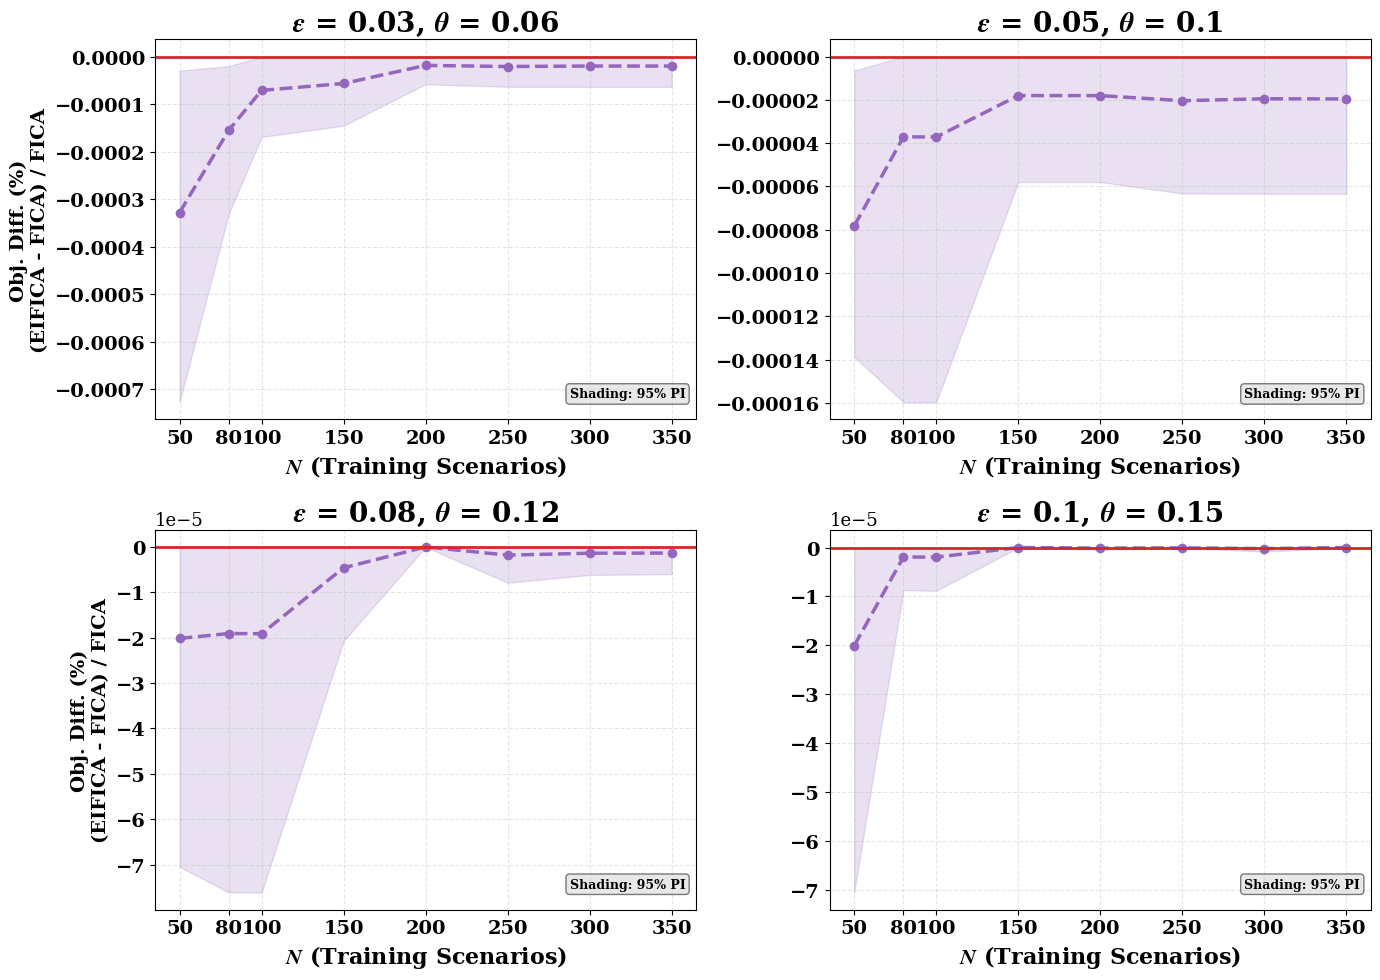


=== Objective-value difference statistics ===
Mean: -0.0000%
std:  0.0001%
|diff| < 0.1%: 100.0%
|diff| < 0.5%: 100.0%


In [16]:
color_diff = sns.color_palette('tab10')[4]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = merged_df[(merged_df['epsilon'] == eps) & (merged_df['theta'] == theta)].copy()

    if not df_plot.empty:
        sns.lineplot(
            x='N_WDR', y='cost_diff_pct', data=df_plot, ax=ax,
            estimator='mean', errorbar=('pi', 95), color=color_diff,
            marker='o', linestyle='--',
            markersize=7, markeredgewidth=0, linewidth=2.5,
        )

    ax.axhline(0, color=sns.color_palette('tab10')[3], linestyle='-', linewidth=2)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Obj. Diff. (%)\n(EIFICA - FICA) / FICA' if i % 2 == 0 else '',
                  fontsize=14, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.text(0.98, 0.05, 'Shading: 95% PI', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

# plt.suptitle('IEEE 118-Bus: Objective Value Difference EIFICA vs FICA',
#              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'case118_obj_diff.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

print('\n=== Objective-value difference statistics ===')
print(f'Mean: {merged_df["cost_diff_pct"].mean():.4f}%')
print(f'std:  {merged_df["cost_diff_pct"].std():.4f}%')
print(f'|diff| < 0.1%: {(merged_df["cost_diff_pct"].abs() < 0.1).mean()*100:.1f}%')
print(f'|diff| < 0.5%: {(merged_df["cost_diff_pct"].abs() < 0.5).mean()*100:.1f}%')